# 01 — Filter sensors to the study set

Three transparent rules are applied to every registered sensor and the decision is recorded. The study area is strict Leeds (a bounding box from `config.py`); indoor and test/undeployed units are excluded. Outputs: a full decision log, the clean study list, and a geographic verification map.

**Note on counts:** the filter keeps 48 sensors by these rules. One of them (SL71 Kentmere) has no data folder on disk, so the next notebook combines 47. The 48 → 47 drop is expected, not a bug.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.config import *
import pandas as pd 

df = pd.read_csv(DATA_DIR / "sensor_summary.csv")
print(df.shape)
df.head()

(68, 12)


,sensor_id,sensor_name,pa_id,lat,lon,location_type,last_modified,last_seen,pm25_a,pm25_b,time_stamp_a,time_stamp_b
0,1,SL71 - Kentmere,51535,53.825920,-1.468594,outdoor,2024-09-05 11:37:29,2026-05-10 14:31:10,1,1,2026-05-10 14:31:10,2026-05-10 14:31:10
1,2,SEE(#2) - UPSURGE - Crossley St,117263,53.930550,-1.389377,indoor,2024-05-09 17:29:19,2024-04-28 02:11:15,0,0,2024-04-28 02:11:15,2024-04-28 02:11:15
2,3,SL050 - Bardsey,131651,53.889965,-1.439765,outdoor,2023-10-18 13:47:20,2026-08-25 06:05:28,0,1,2026-08-25 06:05:28,2026-08-25 06:05:28
3,4,SL055 - Temple Newsam,131655,53.785603,-1.455717,outdoor,2023-08-15 16:20:29,2025-02-17 00:40:07,14,17,2025-02-17 00:40:07,2025-02-17 00:40:07
4,5,SL018 East Ardsley A650,132055,53.725370,-1.550685,outdoor,2022-09-26 15:48:26,2026-01-26 09:17:57,33,28,2026-01-26 09:17:57,2026-01-26 09:17:57


### Apply three selection rules

Each sensor is assessed against:

1. **Geographic** — coordinates must fall inside the Leeds bounding box defined in `config.py` (not sensor name matching, which is unreliable)
2. **Indoor** — project scope is outdoor air quality only
3. **Not a genuine field monitor** — test rigs, UPSURGE experiment units, and undeployed spares are excluded

In [2]:
def assess(row):
    """Return a semicolon-joined string of exclusion reasons; empty string = keep."""
    name = str(row["sensor_name"]).lower()
    loc  = str(row["location_type"]).lower()
    lat, lon = row["lat"], row["lon"]
    reasons = []

    inside = (LEEDS_BOX["lat_min"] < lat < LEEDS_BOX["lat_max"]
              and LEEDS_BOX["lon_min"] < lon < LEEDS_BOX["lon_max"])
    if not inside:
        reasons.append("outside Leeds area")

    if loc == "indoor" or "inside" in name:
        reasons.append("indoor")

    if "not deployed" in name:
        reasons.append("not deployed")
    if any(k in name for k in ["upsurge", "data test", "experimental", "highspeed", "unassigned"]):
        reasons.append("test/experimental")

    return "; ".join(reasons)

df["exclude_reason"] = df.apply(assess, axis=1)
df["keep"] = df["exclude_reason"] == ""
print(f"Keep: {df['keep'].sum()}   Exclude: {(~df['keep']).sum()}")

Keep: 48   Exclude: 20


### Excluded sensors — audit trail

In [3]:
excluded = df[~df["keep"]].sort_values("exclude_reason")
display(excluded[["sensor_name", "lat", "lon", "location_type", "exclude_reason"]])

print("\nExclusions by reason combination:")
print(excluded["exclude_reason"].value_counts().to_string())

,sensor_name,lat,lon,location_type,exclude_reason
10,SL047 (OAKLEA),53.890400,-1.438621,indoor,indoor
34,SL058 - SEE Building 10.102,53.825676,-1.587510,indoor,indoor
35,Ibadan Study OUTSIDE (SL052),53.888240,-1.430587,indoor,indoor
11,SL002 - NOT DEPLOYED,53.805830,-1.555835,indoor,indoor; not deployed
54,SL043 - NOT DEPLOYED,53.889942,-1.439613,indoor,indoor; not deployed
1,SEE(#2) - UPSURGE - Crossley St,53.930550,-1.389377,indoor,indoor; test/experimental
21,SL004 - UPSURGE - Crossley St,53.930702,-1.389783,indoor,indoor; test/experimental
36,SL059 - UPSURGE DATA TEST,53.805077,-1.554896,indoor,indoor; test/experimental
38,SL053 - UPSURGE - Crossley St,53.930454,-1.389116,indoor,indoor; test/experimental
41,SL049 - UPSURGE data test,53.826397,-1.588688,indoor,indoor; test/experimental



Exclusions by reason combination:
exclude_reason
indoor; test/experimental     9
indoor                        3
outside Leeds area; indoor    3
indoor; not deployed          2
outside Leeds area            2
not deployed                  1


### Kept study set

In [4]:
kept = df[df["keep"]].sort_values("sensor_name")
print(f"Study set: {len(kept)} Leeds outdoor sensors")
kept[["sensor_name", "location_type", "lat", "lon", "last_seen"]].sort_values("last_seen",ascending=False)

Study set: 48 Leeds outdoor sensors


,sensor_name,location_type,lat,lon,last_seen
47,SL037 Lotherton Hall,outdoor,53.819187,-1.319971,2026-08-25 06:07:36
67,SL062 Stainburn View,outdoor,53.838860,-1.528167,2026-08-25 06:07:12
46,SL006 - Primrose Hill Primary,outdoor,53.801888,-1.667109,2026-08-25 06:07:10
22,"SL034 - Bramley Library, Hough Lane",outdoor,53.810524,-1.630331,2026-08-25 06:06:48
12,"SL011 - West End Grove, Horsforth",outdoor,53.838055,-1.655033,2026-08-25 06:06:45
15,SL024 Wetherby Town Centre,outdoor,53.928240,-1.386585,2026-08-25 06:06:30
44,SL007 Ninelands Primary,outdoor,53.789272,-1.377445,2026-08-25 06:06:06
57,SL025 - Oakwood,outdoor,53.826885,-1.501485,2026-08-25 06:06:03
32,SL051 - Bramham,outdoor,53.868920,-1.318880,2026-08-25 06:05:52
20,SL016 Scholes Main Street,outdoor,53.825336,-1.429180,2026-08-25 06:05:51


### Save decision log and study list

In [5]:
df[["sensor_id", "sensor_name", "location_type", "lat", "lon",
    "keep", "exclude_reason"]].to_csv(
    Tables / "sensor_filter_decisions.csv", index=False)

kept[["sensor_id", "sensor_name", "location_type", "lat", "lon"]].to_csv(
    Tables / "study_sensors.csv", index=False)

print("Saved:")
print("  outputs/tables/sensor_filter_decisions.csv  (all 68 sensors, with reasons)")
print("  outputs/tables/study_sensors.csv            (the 48 keepers)")

Saved:
  outputs/tables/sensor_filter_decisions.csv  (all 68 sensors, with reasons)
  outputs/tables/study_sensors.csv            (the 48 keepers)


### Map: kept vs excluded

A geographic check that the bounding box did what was intended. The dashed
rectangle is the Leeds box from `config.py`. Excluded sensors within the
plotted area are shown in red (e.g. Long Marston, just outside the box to
the east). A handful of excluded units sit far outside any sensible map
extent for this project (Nigeria, Borneo) and are dropped from the plot
itself rather than squashing the whole map to fit them in -- the complete
list with reasons is in `sensor_filter_decisions.csv`.

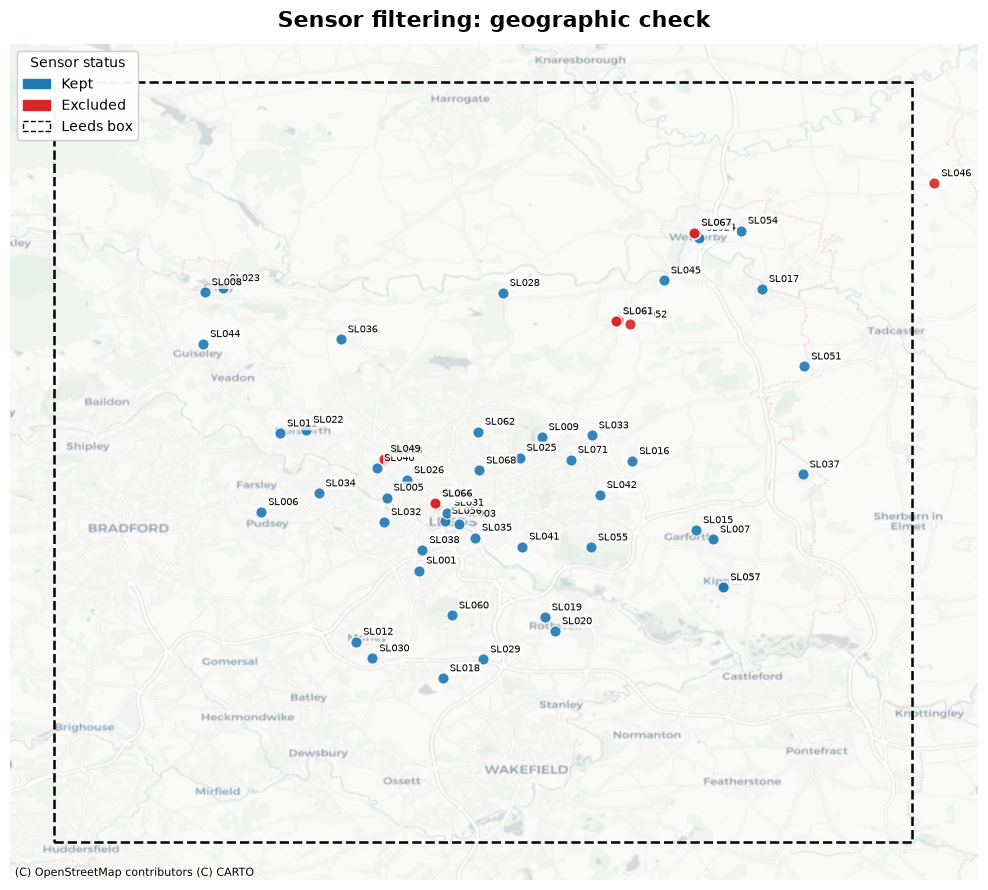

In [6]:
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as cx

def short_label(name):
    """SL0XX where the name has one, a short fallback otherwise -- matches
    the sensor codes used everywhere else in this project, unlike the raw
    sensor_id (1-68) used here previously, which appears nowhere else."""
    m = re.search(r"SL_?(\d+)", name)
    if m:
        return f"SL{int(m.group(1)):03d}"
    return name.split(" - ")[0].split("(")[0].strip()[:10]

# Clip to sensors plausibly near Leeds (removes overseas outliers from the
# plot -- Nigeria and Borneo are real rows in the data but would make this
# map unreadable at any useful zoom level; the full list with reasons is in
# sensor_filter_decisions.csv, saved above).
pad = 0.08
near = df[
    df["lat"].between(LEEDS_BOX["lat_min"] - pad, LEEDS_BOX["lat_max"] + pad) &
    df["lon"].between(LEEDS_BOX["lon_min"] - pad, LEEDS_BOX["lon_max"] + pad)
].copy()
near["label"] = near["sensor_name"].map(short_label)

fig, ax = plt.subplots(figsize=(10, 9))

for keep_flag, colour, label in [(True, "tab:blue", "Kept"),
                                  (False, "tab:red", "Excluded")]:
    sub = near[near["keep"] == keep_flag]
    ax.scatter(sub["lon"], sub["lat"], c=colour, s=65, label=label,
              edgecolor="white", linewidth=0.8, alpha=0.9, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row["label"], (row["lon"], row["lat"]),
                    xytext=(5, 5), textcoords="offset points", fontsize=7.5,
                    zorder=5, bbox=dict(boxstyle="round,pad=0.12", fc="white",
                                        ec="none", alpha=0.75))

b = LEEDS_BOX
ax.add_patch(mpatches.Rectangle(
    (b["lon_min"], b["lat_min"]), b["lon_max"] - b["lon_min"], b["lat_max"] - b["lat_min"],
    fill=False, edgecolor="black", linestyle="--", linewidth=1.8, zorder=4))

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
ax.set_axis_off()
ax.legend(handles=[
    mpatches.Patch(color="tab:blue", label="Kept"),
    mpatches.Patch(color="tab:red", label="Excluded"),
    mpatches.Patch(facecolor="none", edgecolor="black", linestyle="--", label="Leeds box"),
], loc="upper left", frameon=True, framealpha=0.95, title="Sensor status")
ax.set_title("Sensor filtering: geographic check", fontsize=16, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(Figures / "01_sensor_filter_map.png", dpi=300, bbox_inches="tight")
plt.show()